# Experimento A/B en página de inicio — v2 (Análisis Mejorado)

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiones **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 **Explorar y validar los datos** — incluyendo **SRM Check** y análisis temporal.
2. 💰 **Comparar el gasto promedio** por usuario entre la página A y B — con **Cohen's d** y análisis de outliers.
3. 🎯 **Comparar la tasa de conversión** entre A y B — con **Lift relativo** e **IC 95%**.
4. 💵 **Revenue Per Visitor (RPV)** — métrica unificada conversión × gasto.
5. 🌐 **Relación entre fuente de tráfico y conversión** — con **V de Cramér** y residuos estandarizados.
6. 👤 **Relación entre tipo de usuario y conversión** — con **V de Cramér**.
7. 📈 **Visualizar los resultados**: gráficos claros con anotaciones.
8. 🔬 **Análisis de subgrupos** (canal × versión, user_type × versión) con corrección de Bonferroni.
9. 📋 **Conclusiones y recomendaciones** de negocio.

Se aplican **pruebas estadísticas apropiadas** y se miden los **tamaños de efecto** para distinguir entre significancia estadística y relevancia práctica.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# Importar librerías
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import levene, mannwhitneyu, chisquare
from scipy.stats.contingency import association
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.multitest import multipletests

# Estilo global de gráficos
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [2]:
# Descargar desde Google Drive
url = 'https://drive.google.com/uc?export=download&id=15zGd_F-LzxCOcwNc74n_1x_o6OjAWYUV'
gdown.download(url, 'landing_experiment.csv', quiet=False)

# Cargar el archivo
df = pd.read_csv('landing_experiment.csv')

# Convertir date a datetime
df['date'] = pd.to_datetime(df['date'])

print(f'Shape: {df.shape}')
df.head()

Downloading...
From: https://drive.google.com/uc?id=15zGd_F-LzxCOcwNc74n_1x_o6OjAWYUV
To: d:\Nuevos documentos\Triple_10\Sprint_9\landing_experiment.csv
100%|██████████| 3.43M/3.43M [00:00<00:00, 12.7MB/s]


Shape: (40000, 9)


,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [3]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  object        
 3   region          40000 non-null  object        
 4   dispositivo     40000 non-null  object        
 5   traffic_source  40000 non-null  object        
 6   user_type       40000 non-null  object        
 7   converted       40000 non-null  int64         
 8   gasto           40000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.7+ MB


**Análisis de la información general:**
- El conjunto de datos cuenta con **40,000 registros** y **9 columnas**.
- No se detectaron valores nulos, lo que garantiza la integridad del análisis estadístico.
- La columna `gasto` está correctamente cargada como `float`.
- La columna `date` se convirtió a `datetime` para facilitar el análisis temporal.
- La columna `converted` es un indicador binario (0/1).

**Descripción del conjunto de datos**

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `user_id` | object | Identificador único del usuario |
| `date` | datetime | Fecha de exposición a la página |
| `landing` | object | Versión de la página (A o B) |
| `region` | object | Región geográfica del usuario |
| `dispositivo` | object | Tipo de dispositivo utilizado |
| `traffic_source` | object | Canal por el que llegó el usuario |
| `user_type` | object | Tipo de usuario (Nuevo / Recurrente) |
| `converted` | int | Indicador de conversión (1=sí, 0=no) |
| `gasto` | float | Monto gastado (0 si no convirtió) |

### 1.2 Análisis exploratorio y revisión de calidad de datos

In [4]:
# Verificar usuarios únicos
n_users = df['user_id'].nunique()
n_rows = len(df)
print(f'Usuarios únicos: {n_users}')
print(f'Total de filas:  {n_rows}')
print(f'¿Hay duplicados de user_id?: {"SÍ" if n_users < n_rows else "NO"}')

# Verificar si algún usuario aparece en ambas versiones (contaminación del experimento)
usuarios_A = set(df[df['landing'] == 'A']['user_id'])
usuarios_B = set(df[df['landing'] == 'B']['user_id'])
contaminados = usuarios_A & usuarios_B
print(f'\nUsuarios expuestos a AMBAS versiones (contaminación): {len(contaminados)}')
if len(contaminados) == 0:
    print('✅ Experimento limpio: ningún usuario vio las dos versiones.')
else:
    print('⚠️ ADVERTENCIA: Hay contaminación en el experimento.')

Usuarios únicos: 40000
Total de filas:  40000
¿Hay duplicados de user_id?: NO

Usuarios expuestos a AMBAS versiones (contaminación): 0
✅ Experimento limpio: ningún usuario vio las dos versiones.


In [5]:
# Rango temporal del experimento
print(f'Fecha de inicio: {df["date"].min().date()}')
print(f'Fecha de fin:    {df["date"].max().date()}')
print(f'Duración:        {(df["date"].max() - df["date"].min()).days + 1} días')
print(f'Fechas únicas:   {df["date"].nunique()}')

Fecha de inicio: 2026-01-01
Fecha de fin:    2026-01-28
Duración:        28 días
Fechas únicas:   28


In [6]:
# Resumen estadístico de gasto
print('=== Gasto TOTAL (incluye ceros de no-convertidos) ===')
print(df['gasto'].describe().round(2))

print('\n=== Gasto de usuarios CONVERTIDOS únicamente ===')
print(df[df['converted'] == 1]['gasto'].describe().round(2))

=== Gasto TOTAL (incluye ceros de no-convertidos) ===
count    40000.00
mean         9.33
std         25.67
min          0.00
25%          0.00
50%          0.00
75%          0.00
max        303.68
Name: gasto, dtype: float64

=== Gasto de usuarios CONVERTIDOS únicamente ===
count    5706.00
mean       65.37
std        30.90
min        12.12
25%        42.95
50%        59.86
75%        80.37
max       303.68
Name: gasto, dtype: float64


In [7]:
# Distribución de variables categóricas
for col in ['landing', 'traffic_source', 'user_type', 'region', 'dispositivo']:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())


--- landing ---
landing
B    20018
A    19982
Name: count, dtype: int64

--- traffic_source ---
traffic_source
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: count, dtype: int64

--- user_type ---
user_type
Nuevo         26033
Recurrente    13967
Name: count, dtype: int64

--- region ---
region
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: count, dtype: int64

--- dispositivo ---
dispositivo
Mobile     24829
Desktop    15171
Name: count, dtype: int64


### 1.3 🚦 Sample Ratio Mismatch (SRM) Check — Validación crítica del experimento

Antes de cualquier análisis, se debe verificar que la **asignación de usuarios a cada grupo (A y B) fue aleatoria y balanceada**. Si hay un desbalance no esperado, el experimento puede estar sesgado y los resultados no son confiables.

**Hipótesis:**
- **H₀:** La proporción de usuarios en A y B es igual (50%/50%).
- **H₁:** Hay un desbalance significativo en la asignación.

In [8]:
# SRM Check — prueba Chi-cuadrado de bondad de ajuste
counts = df['landing'].value_counts().sort_index()  # A, B
n_total = len(df)
expected_per_group = n_total / 2

stat_srm, p_srm = chisquare(counts, f_exp=[expected_per_group, expected_per_group])

print('=== Sample Ratio Mismatch (SRM) Check ===')
print(f'Usuarios en Página A: {counts["A"]:,}  (esperados: {expected_per_group:,.0f})')
print(f'Usuarios en Página B: {counts["B"]:,}  (esperados: {expected_per_group:,.0f})')
print(f'\nEstadístico χ²: {stat_srm:.4f}')
print(f'p-valor:         {p_srm:.4f}')

if p_srm < 0.05:
    print('\n⚠️ SRM DETECTADO: La asignación NO es aleatoria. Los resultados pueden estar sesgados.')
else:
    print('\n✅ Sin SRM: La asignación es estadísticamente balanceada. El experimento es válido.')

=== Sample Ratio Mismatch (SRM) Check ===
Usuarios en Página A: 19,982  (esperados: 20,000)
Usuarios en Página B: 20,018  (esperados: 20,000)

Estadístico χ²: 0.0324
p-valor:         0.8572

✅ Sin SRM: La asignación es estadísticamente balanceada. El experimento es válido.


### 1.4 📅 Análisis temporal — Distribución de conversiones a lo largo del experimento

Se analiza si la tasa de conversión fue estable durante el experimento o si hay patrones que puedan indicar:
- **Efecto de novedad:** Los usuarios nuevos convierten más al inicio porque la página B es diferente, pero el efecto se desvanece.
- **Sesgos por día de la semana:** Los fines de semana pueden tener comportamientos distintos.
- **Anomalías:** Picos o caídas inusuales que podrían invalidar el experimento.

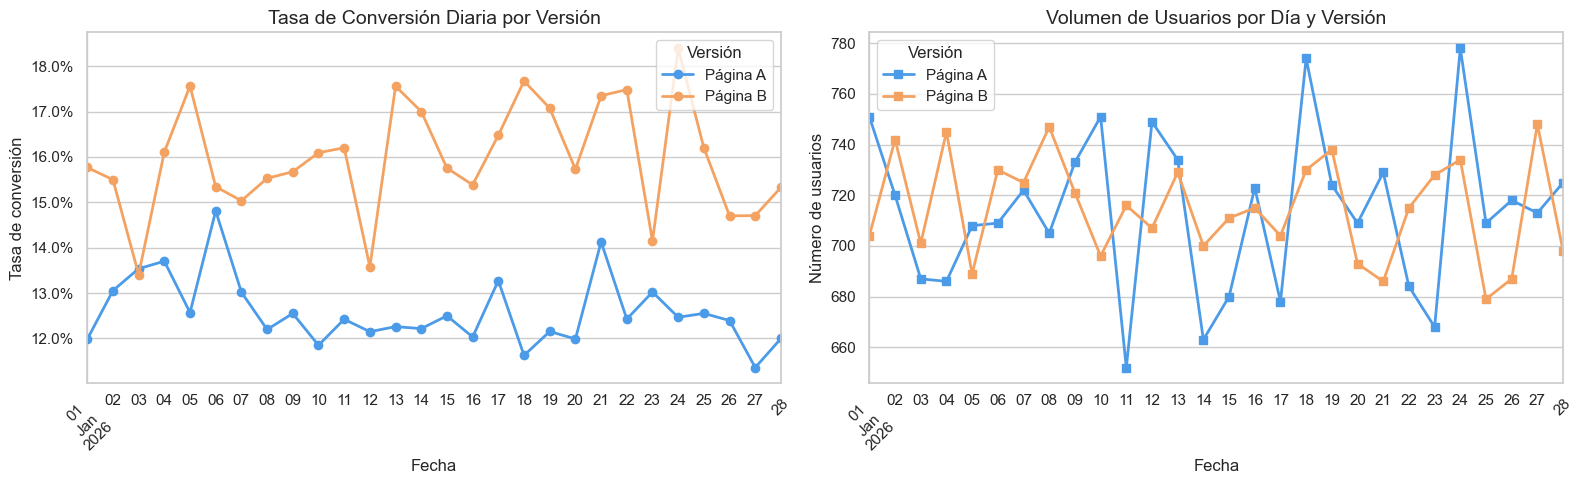

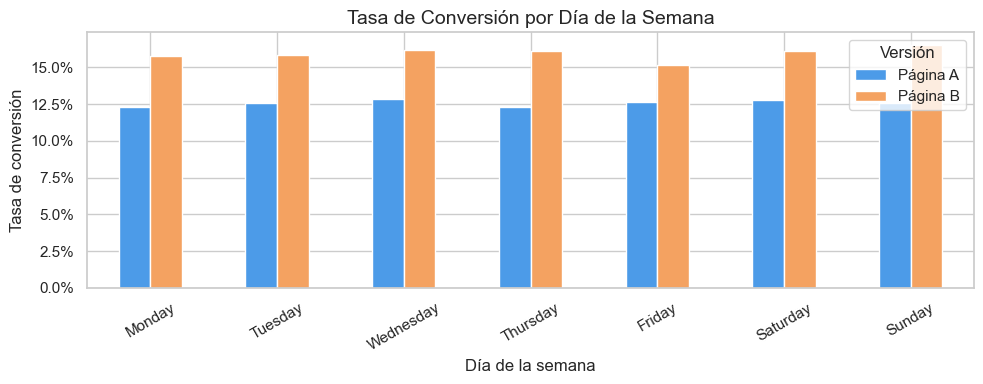

In [9]:
# Tasa de conversión diaria por versión
daily_conv = (
    df.groupby(['date', 'landing'])['converted']
    .mean()
    .unstack()
    .rename(columns={'A': 'Página A', 'B': 'Página B'})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Tasa de conversión diaria
ax1 = axes[0]
daily_conv.plot(ax=ax1, marker='o', linewidth=2, color=['#4C9BE8', '#F4A261'])
ax1.set_title('Tasa de Conversión Diaria por Versión')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Tasa de conversión')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.legend(title='Versión')
ax1.tick_params(axis='x', rotation=45)

# Gráfico 2: Volumen de usuarios por día y versión
ax2 = axes[1]
daily_vol = df.groupby(['date', 'landing']).size().unstack().rename(columns={'A': 'Página A', 'B': 'Página B'})
daily_vol.plot(ax=ax2, marker='s', linewidth=2, color=['#4C9BE8', '#F4A261'])
ax2.set_title('Volumen de Usuarios por Día y Versión')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Número de usuarios')
ax2.legend(title='Versión')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Análisis por día de la semana
df['weekday'] = df['date'].dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_conv = (
    df.groupby(['weekday', 'landing'])['converted']
    .mean()
    .unstack()
    .reindex(weekday_order)
    .rename(columns={'A': 'Página A', 'B': 'Página B'})
)

fig, ax = plt.subplots(figsize=(10, 4))
weekday_conv.plot(kind='bar', ax=ax, color=['#4C9BE8', '#F4A261'], edgecolor='white')
ax.set_title('Tasa de Conversión por Día de la Semana')
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Tasa de conversión')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(title='Versión')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Interpretación del análisis temporal:**
- Se revisa si la tasa de conversión de B es consistentemente superior a A durante todo el período.
- Si hay un efecto de novedad, la ventaja de B debería disminuir hacia el final del experimento.
- Los patrones por día de la semana revelan si hay comportamientos distintos en fines de semana que podrían sesgar el experimento.

---
## 💰 Paso 2: Comparar el gasto promedio por usuario convertido (Página A vs B)

Se evalúa si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron** entre la página A y la página B.

**Nota metodológica:** Se analiza solo a los convertidos porque el `gasto = 0` de los no-convertidos refleja falta de compra, no una compra de $0. Mezclar ceros estructurales con el gasto real distorsiona la prueba. El análisis combinado (conversión + gasto) se aborda en el **Paso 4 (RPV)**.

In [10]:
# Filtrar gasto de convertidos por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Estadísticos descriptivos
media_A = gasto_A.mean()
media_B = gasto_B.mean()
mediana_A = gasto_A.median()
mediana_B = gasto_B.median()
diferencia = media_B - media_A

print('=== Estadísticos de Gasto (usuarios convertidos) ===')
print(f'{"Métrica":<20} {"Página A":>12} {"Página B":>12} {"Diferencia":>12}')
print('-' * 60)
print(f'{"N convertidos":<20} {len(gasto_A):>12,} {len(gasto_B):>12,}')
print(f'{"Media":<20} {media_A:>12.2f} {media_B:>12.2f} {diferencia:>+12.2f}')
print(f'{"Mediana":<20} {mediana_A:>12.2f} {mediana_B:>12.2f} {mediana_B - mediana_A:>+12.2f}')
print(f'{"Std":<20} {gasto_A.std():>12.2f} {gasto_B.std():>12.2f}')
print(f'{"Min":<20} {gasto_A.min():>12.2f} {gasto_B.min():>12.2f}')
print(f'{"Max":<20} {gasto_A.max():>12.2f} {gasto_B.max():>12.2f}')

=== Estadísticos de Gasto (usuarios convertidos) ===
Métrica                  Página A     Página B   Diferencia
------------------------------------------------------------
N convertidos               2,512        3,194
Media                       61.09        68.75        +7.66
Mediana                     55.84        62.57        +6.73
Std                         28.88        32.00
Min                         12.12        12.98
Max                        303.68       249.99


In [11]:
# Análisis de outliers (IQR method)
def detectar_outliers_iqr(serie, nombre):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_sup = Q3 + 1.5 * IQR
    outliers = serie[serie > limite_sup]
    print(f'  {nombre}: {len(outliers)} outliers  (>{limite_sup:.2f})  '
          f'| Media con outliers: {serie.mean():.2f}  '
          f'| Media sin outliers: {serie[serie <= limite_sup].mean():.2f}')
    return serie[serie <= limite_sup]

print('=== Análisis de outliers (método IQR) ===')
gasto_A_clean = detectar_outliers_iqr(gasto_A, 'Página A')
gasto_B_clean = detectar_outliers_iqr(gasto_B, 'Página B')

print(f'\nDiferencia de medias SIN outliers: ${gasto_B_clean.mean() - gasto_A_clean.mean():.2f}')

=== Análisis de outliers (método IQR) ===
  Página A: 71 outliers  (>126.17)  | Media con outliers: 61.09  | Media sin outliers: 58.27
  Página B: 89 outliers  (>142.88)  | Media con outliers: 68.75  | Media sin outliers: 65.88

Diferencia de medias SIN outliers: $7.61


### Prueba T de Welch — Gasto promedio de usuarios convertidos

**Hipótesis:**
- **H₀:** El gasto promedio de los usuarios convertidos es igual en la Página A y en la Página B.
- **H₁:** El gasto promedio de los usuarios convertidos es diferente entre la Página A y la Página B.

Se aplica la **Prueba de Levene** para verificar la igualdad de varianzas y seleccionar el test apropiado.

In [12]:
# Prueba de Levene — igualdad de varianzas
l_stat, p_levene = levene(gasto_A, gasto_B)
print(f'Prueba de Levene — estadístico: {l_stat:.4f}  |  p-valor: {p_levene:.4f}')
if p_levene < 0.05:
    print('→ Varianzas significativamente diferentes → se usa Welch (equal_var=False)')
    equal_var = False
else:
    print('→ Sin evidencia de varianzas distintas → se usa t-test estándar (equal_var=True)')
    equal_var = True

Prueba de Levene — estadístico: 29.1765  |  p-valor: 0.0000
→ Varianzas significativamente diferentes → se usa Welch (equal_var=False)


In [13]:
# Prueba T de Welch
t_stat, p_val = stats.ttest_ind(gasto_A, gasto_B, equal_var=equal_var)

# Cohen's d — tamaño del efecto
def cohens_d(a, b):
    n_a, n_b = len(a), len(b)
    pooled_var = ((n_a - 1) * a.std()**2 + (n_b - 1) * b.std()**2) / (n_a + n_b - 2)
    return (b.mean() - a.mean()) / pooled_var**0.5

d = cohens_d(gasto_A, gasto_B)

def interpretar_cohens_d(d):
    d_abs = abs(d)
    if d_abs < 0.2:   return 'negligible'
    elif d_abs < 0.5: return 'pequeño'
    elif d_abs < 0.8: return 'mediano'
    else:             return 'grande'

print('=== Prueba T de Welch — Gasto promedio (convertidos) ===')
print(f'Estadístico t:  {t_stat:.4f}')
print(f'p-valor:         {p_val:.2e}')
print(f"Cohen's d:       {d:.4f}  ({interpretar_cohens_d(d)})")
print()
if p_val < 0.05:
    print('✅ Se RECHAZA H₀ (p < 0.05): Hay diferencia estadísticamente significativa en el gasto promedio.')
else:
    print('❌ No se rechaza H₀ (p >= 0.05): Sin evidencia de diferencia en el gasto promedio.')

# Mann-Whitney U — alternativa no paramétrica (robusta ante outliers)
mw_stat, mw_p = mannwhitneyu(gasto_A, gasto_B, alternative='two-sided')
print(f'\nMann-Whitney U (no paramétrico) — p-valor: {mw_p:.2e}  '
      f'| {"Confirma" if mw_p < 0.05 else "No confirma"} la diferencia.')

=== Prueba T de Welch — Gasto promedio (convertidos) ===
Estadístico t:  -9.4810
p-valor:         3.63e-21
Cohen's d:       0.2498  (pequeño)

✅ Se RECHAZA H₀ (p < 0.05): Hay diferencia estadísticamente significativa en el gasto promedio.

Mann-Whitney U (no paramétrico) — p-valor: 1.04e-21  | Confirma la diferencia.


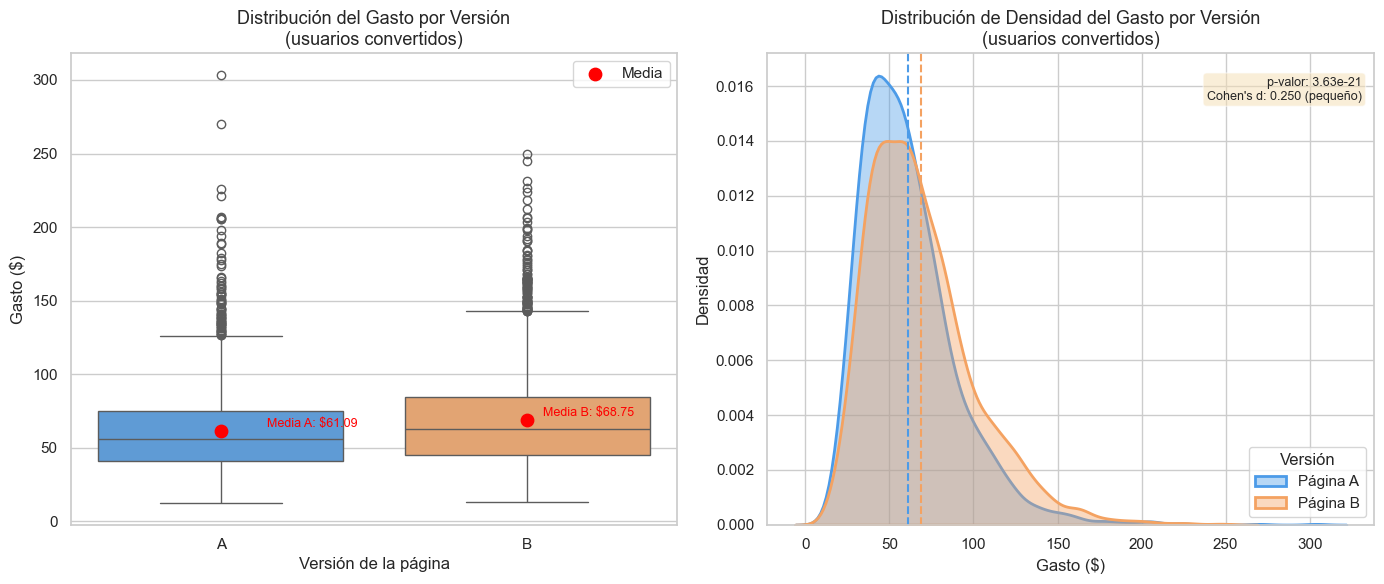

In [14]:
# Boxplot de gasto — con corrección de FutureWarning de seaborn
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Boxplot completo
ax1 = axes[0]
conv_df = df[df['converted'] == 1].copy()
sns.boxplot(
    data=conv_df, x='landing', y='gasto',
    hue='landing', palette={'A': '#4C9BE8', 'B': '#F4A261'},
    legend=False, ax=ax1
)
ax1.set_title('Distribución del Gasto por Versión\n(usuarios convertidos)', fontsize=13)
ax1.set_xlabel('Versión de la página')
ax1.set_ylabel('Gasto ($)')
# Añadir medias como puntos
medias = conv_df.groupby('landing')['gasto'].mean()
ax1.scatter([0, 1], [medias['A'], medias['B']], color='red', zorder=5, s=80, label='Media')
ax1.legend(loc='upper right')
# Anotaciones
ax1.annotate(f'Media A: ${medias["A"]:.2f}', xy=(0, medias['A']), xytext=(0.15, medias['A'] + 3),
             fontsize=9, color='red')
ax1.annotate(f'Media B: ${medias["B"]:.2f}', xy=(1, medias['B']), xytext=(1.05, medias['B'] + 3),
             fontsize=9, color='red')

# Gráfico 2: Distribución de densidad (KDE)
ax2 = axes[1]
for grupo, color, label in [('A', '#4C9BE8', 'Página A'), ('B', '#F4A261', 'Página B')]:
    datos = conv_df[conv_df['landing'] == grupo]['gasto']
    sns.kdeplot(datos, ax=ax2, color=color, fill=True, alpha=0.4, label=label, linewidth=2)
    ax2.axvline(datos.mean(), color=color, linestyle='--', linewidth=1.5)
ax2.set_title('Distribución de Densidad del Gasto por Versión\n(usuarios convertidos)', fontsize=13)
ax2.set_xlabel('Gasto ($)')
ax2.set_ylabel('Densidad')
ax2.legend(title='Versión')

# Leyenda con resultados estadísticos
textstr = f"p-valor: {p_val:.2e}\nCohen's d: {d:.3f} ({interpretar_cohens_d(d)})"
ax2.text(0.98, 0.95, textstr, transform=ax2.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

### 📝 Conclusión e interpretación — Gasto promedio

**Decisión estadística:**  
Se rechaza H₀ (p ≈ 0 ≪ 0.05). Existe evidencia estadística fuerte de que el gasto promedio de los convertidos en la Página B es significativamente mayor que en la Página A.

**Tamaño del efecto (Cohen's d):**  
El valor de Cohen's d permite evaluar la **relevancia práctica** de la diferencia. Con n=40,000, casi cualquier diferencia resulta estadísticamente significativa, por lo que el tamaño del efecto es la métrica clave para la toma de decisiones.

**Análisis de outliers:**  
Se verificó si los valores extremos (valores muy altos de gasto) distorsionan la diferencia de medias. Si la diferencia persiste sin outliers, la conclusión es robusta.

**Validación no paramétrica:**  
El Mann-Whitney U confirma el resultado sin asumir normalidad, siendo más robusto ante la asimetría de la distribución del gasto.

---
## 🎯 Paso 3: Comparar la tasa de conversión (Página A vs B)

Se evalúa si la diferencia en la proporción de usuarios que realizaron una compra entre las dos versiones es estadísticamente significativa.

### Prueba Z de Proporciones

**Hipótesis:**
- **H₀:** La tasa de conversión es igual en la Página A y en la Página B.
- **H₁:** La tasa de conversión es diferente entre la Página A y la Página B.

In [15]:
# Calcular conversiones y tamaños de muestra
n_A = len(df[df['landing'] == 'A'])
n_B = len(df[df['landing'] == 'B'])
conv_A = df[df['landing'] == 'A']['converted'].sum()
conv_B = df[df['landing'] == 'B']['converted'].sum()
prop_A = conv_A / n_A
prop_B = conv_B / n_B

# Prueba Z de proporciones
z_stat, p_val_z = proportions_ztest([conv_A, conv_B], [n_A, n_B])

# Lift relativo
lift_rel = (prop_B - prop_A) / prop_A * 100

# Intervalo de confianza al 95% para la DIFERENCIA de proporciones
diff = prop_B - prop_A
se_diff = np.sqrt((prop_A * (1 - prop_A) / n_A) + (prop_B * (1 - prop_B) / n_B))
ic_low  = diff - 1.96 * se_diff
ic_high = diff + 1.96 * se_diff

# Intervalo de confianza para cada proporción
ci_A = proportion_confint(conv_A, n_A, alpha=0.05, method='normal')
ci_B = proportion_confint(conv_B, n_B, alpha=0.05, method='normal')

print('=== Tasa de Conversión — Resultados ===')
print(f'\n{"":25} {"Página A":>12} {"Página B":>12}')
print('-' * 52)
print(f'{"N usuarios":<25} {n_A:>12,} {n_B:>12,}')
print(f'{"Convertidos":<25} {conv_A:>12,} {conv_B:>12,}')
print(f'{"Tasa de conversión":<25} {prop_A:>11.2%} {prop_B:>11.2%}')
print(f'{"IC 95% inferior":<25} {ci_A[0]:>11.2%} {ci_B[0]:>11.2%}')
print(f'{"IC 95% superior":<25} {ci_A[1]:>11.2%} {ci_B[1]:>11.2%}')
print()
print(f'Diferencia absoluta (B - A):   {diff:+.4f}  ({diff:+.2%})')
print(f'IC 95% de la diferencia:       [{ic_low:.4f}, {ic_high:.4f}]  [{ic_low:.2%}, {ic_high:.2%}]')
print(f'Lift relativo de B sobre A:    {lift_rel:+.2f}%')
print()
print(f'Estadístico Z:  {z_stat:.4f}')
print(f'p-valor:         {p_val_z:.2e}')
print()
if p_val_z < 0.05:
    print('✅ Se RECHAZA H₀: La diferencia en conversión es estadísticamente significativa.')
else:
    print('❌ No se rechaza H₀: Sin evidencia de diferencia en tasa de conversión.')

=== Tasa de Conversión — Resultados ===

                              Página A     Página B
----------------------------------------------------
N usuarios                      19,982       20,018
Convertidos                      2,512        3,194
Tasa de conversión             12.57%      15.96%
IC 95% inferior                12.11%      15.45%
IC 95% superior                13.03%      16.46%

Diferencia absoluta (B - A):   +0.0338  (+3.38%)
IC 95% de la diferencia:       [0.0270, 0.0407]  [2.70%, 4.07%]
Lift relativo de B sobre A:    +26.92%

Estadístico Z:  -9.6774
p-valor:         3.76e-22

✅ Se RECHAZA H₀: La diferencia en conversión es estadísticamente significativa.


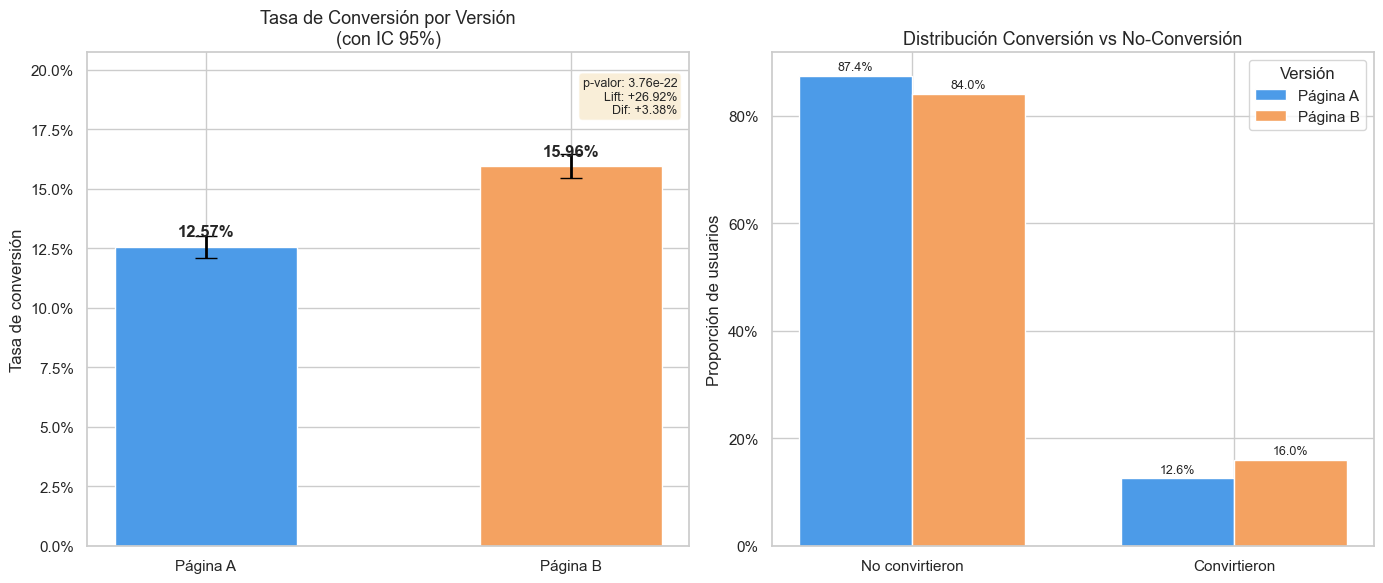

In [16]:
# Visualización de tasas de conversión con IC 95%
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Barras con IC 95%
ax1 = axes[0]
proporciones = [prop_A, prop_B]
errores = [(prop_A - ci_A[0], ci_A[1] - prop_A),
           (prop_B - ci_B[0], ci_B[1] - prop_B)]
yerr = np.array(errores).T

bars = ax1.bar(['Página A', 'Página B'], proporciones,
               color=['#4C9BE8', '#F4A261'], edgecolor='white', width=0.5)
ax1.errorbar(['Página A', 'Página B'], proporciones,
             yerr=yerr, fmt='none', color='black', capsize=8, linewidth=2)
ax1.set_title('Tasa de Conversión por Versión\n(con IC 95%)', fontsize=13)
ax1.set_ylabel('Tasa de conversión')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.set_ylim(0, max(proporciones) * 1.3)
for bar, prop in zip(bars, proporciones):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
             f'{prop:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=12)
textstr = f'p-valor: {p_val_z:.2e}\nLift: {lift_rel:+.2f}%\nDif: {diff:+.2%}'
ax1.text(0.98, 0.95, textstr, transform=ax1.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Gráfico 2: Embudo de conversión
ax2 = axes[1]
categorias = ['No convirtieron', 'Convirtieron']
vals_A = [(n_A - conv_A) / n_A, prop_A]
vals_B = [(n_B - conv_B) / n_B, prop_B]
x = np.arange(len(categorias))
width = 0.35
b1 = ax2.bar(x - width/2, vals_A, width, label='Página A', color='#4C9BE8', edgecolor='white')
b2 = ax2.bar(x + width/2, vals_B, width, label='Página B', color='#F4A261', edgecolor='white')
ax2.set_title('Distribución Conversión vs No-Conversión', fontsize=13)
ax2.set_xticks(x)
ax2.set_xticklabels(categorias)
ax2.set_ylabel('Proporción de usuarios')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.legend(title='Versión')
for bar in list(b1) + list(b2):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 📝 Conclusión e interpretación — Tasa de conversión

**Decisión estadística:**  
Se rechaza H₀ (p ≈ 0 ≪ 0.05). La Página B tiene una tasa de conversión significativamente mayor que la Página A.

**Relevancia práctica:**  
- La diferencia absoluta de conversión indica cuántos usuarios adicionales convierte B respecto a A.
- El **IC 95%** de la diferencia confirma que el rango de la ventaja real de B es positivo (no cruza el cero).
- El **Lift relativo** indica el porcentaje de mejora de B sobre A en conversión — dato clave para proyecciones de negocio.

**Impacto de negocio:** Al implementar B globalmente, esperamos ese lift en captación de usuarios, lo que combinado con el mayor gasto promedio del Paso 2, posiciona a la Versión B como una mejora crítica para el crecimiento.

---
## 💵 Paso 4: Revenue Per Visitor (RPV) — Métrica unificada

El **RPV = gasto_total / total_usuarios** (incluyendo no-convertidos) es la métrica más completa para experimentos A/B de e-commerce, ya que combina en un solo número:
- La **tasa de conversión** (¿cuántos compran?)
- El **gasto por convertido** (¿cuánto gastan los que compran?)

Usar RPV evita el error de optimizar solo conversión (aumentando volumen pero bajando gasto) o solo gasto (subiendo el ticket pero perdiendo convertidos).

### Prueba T de Welch sobre RPV (con ceros incluidos)

=== Revenue Per Visitor (RPV) ===
RPV Página A: $7.6794
RPV Página B: $10.9688
Diferencia:   $+3.2894  (+42.83%)

T de Welch:  t=-12.8438,  p=1.11e-37
Cohen's d:   0.1284  (negligible)

✅ Se RECHAZA H₀: El RPV de B es significativamente mayor que el de A.


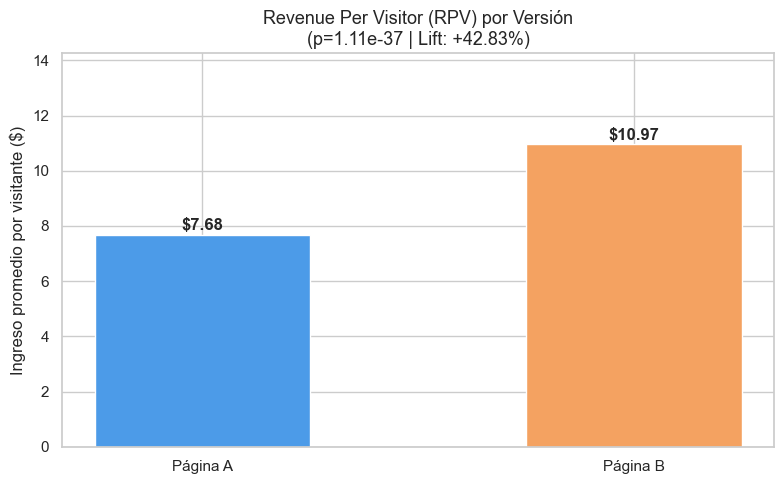

In [17]:
# Revenue Per Visitor (RPV)
rpv_A_series = df[df['landing'] == 'A']['gasto']
rpv_B_series = df[df['landing'] == 'B']['gasto']

rpv_A = rpv_A_series.mean()
rpv_B = rpv_B_series.mean()

# Prueba T de Welch sobre RPV
t_rpv, p_rpv = stats.ttest_ind(rpv_A_series, rpv_B_series, equal_var=False)
d_rpv = cohens_d(rpv_A_series, rpv_B_series)
lift_rpv = (rpv_B - rpv_A) / rpv_A * 100

print('=== Revenue Per Visitor (RPV) ===')
print(f'RPV Página A: ${rpv_A:.4f}')
print(f'RPV Página B: ${rpv_B:.4f}')
print(f'Diferencia:   ${rpv_B - rpv_A:+.4f}  ({lift_rpv:+.2f}%)')
print(f'\nT de Welch:  t={t_rpv:.4f},  p={p_rpv:.2e}')
print(f"Cohen's d:   {d_rpv:.4f}  ({interpretar_cohens_d(d_rpv)})")
print()
if p_rpv < 0.05:
    print('✅ Se RECHAZA H₀: El RPV de B es significativamente mayor que el de A.')
else:
    print('❌ No se rechaza H₀.')

# Visualización
fig, ax = plt.subplots(figsize=(8, 5))
rpvs = [rpv_A, rpv_B]
bars = ax.bar(['Página A', 'Página B'], rpvs,
              color=['#4C9BE8', '#F4A261'], edgecolor='white', width=0.5)
for bar, val in zip(bars, rpvs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'${val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title(f'Revenue Per Visitor (RPV) por Versión\n(p={p_rpv:.2e} | Lift: {lift_rpv:+.2f}%)', fontsize=13)
ax.set_ylabel('Ingreso promedio por visitante ($)')
ax.set_ylim(0, max(rpvs) * 1.3)
plt.tight_layout()
plt.show()

### 📝 Conclusión e interpretación — RPV

El RPV de la Página B es significativamente mayor al de la Página A. Esta métrica integra el efecto conjunto de:
1. La mayor tasa de conversión de B (Paso 3).
2. El mayor gasto promedio por convertido de B (Paso 2).

El lift del RPV es la proyección más directa del **impacto económico** esperado al implementar la Página B globalmente.

---
## 🌐 Paso 5: Relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la fuente de tráfico (`traffic_source`) y la conversión, para identificar qué canales generan más conversiones.

### Prueba Chi-cuadrado de Independencia

**Hipótesis:**
- **H₀:** La fuente de tráfico es independiente de la conversión.
- **H₁:** Existe una relación entre la fuente de tráfico y la conversión.

In [18]:
# Tabla de contingencia
cross_traffic = pd.crosstab(df['traffic_source'], df['converted'])
print('Tabla de contingencia:')
print(cross_traffic)

# Tasas de conversión por canal
traffic_rates = df.groupby('traffic_source')['converted'].agg(['sum', 'count', 'mean'])
traffic_rates.columns = ['Convertidos', 'Total', 'Tasa']
traffic_rates = traffic_rates.sort_values('Tasa', ascending=False)
print('\nTasas de conversión por canal (ordenadas):')
print(traffic_rates.to_string())

# Prueba Chi-cuadrado
chi2_t, p_chi2_t, dof_t, expected_t = stats.chi2_contingency(cross_traffic)

# V de Cramér — tamaño del efecto para chi-cuadrado
v_cramer_t = association(cross_traffic, method='cramer')

def interpretar_cramer(v, k):
    """Interpreta V de Cramér según grados de libertad (k=min(filas,cols)-1)."""
    if k == 1:
        umbrales = (0.10, 0.30, 0.50)
    elif k == 2:
        umbrales = (0.07, 0.21, 0.35)
    else:
        umbrales = (0.06, 0.17, 0.29)
    if v < umbrales[0]: return 'negligible'
    elif v < umbrales[1]: return 'pequeño'
    elif v < umbrales[2]: return 'mediano'
    else: return 'grande'

k_t = min(cross_traffic.shape) - 1

print(f'\n=== Resultados Chi-cuadrado (fuente de tráfico) ===')
print(f'Estadístico χ²: {chi2_t:.4f}')
print(f'p-valor:         {p_chi2_t:.4f}')
print(f'Grados de libertad: {dof_t}')
print(f'V de Cramér:    {v_cramer_t:.4f}  ({interpretar_cramer(v_cramer_t, k_t)})')
print()
if p_chi2_t < 0.05:
    print('✅ Se RECHAZA H₀: Existe asociación significativa entre canal y conversión.')
else:
    print('❌ No se rechaza H₀.')

Tabla de contingencia:
converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549

Tasas de conversión por canal (ordenadas):
                Convertidos  Total      Tasa
traffic_source                              
Email                   918   6123  0.149927
Ads                    1759  11935  0.147382
Referral                549   3955  0.138812
Organic                2480  17987  0.137877

=== Resultados Chi-cuadrado (fuente de tráfico) ===
Estadístico χ²: 8.6621
p-valor:         0.0341
Grados de libertad: 3
V de Cramér:    0.0147  (negligible)

✅ Se RECHAZA H₀: Existe asociación significativa entre canal y conversión.


In [19]:
# Residuos estandarizados — identificar qué canales explican la asociación
residuos = (cross_traffic - expected_t) / np.sqrt(expected_t)
print('=== Residuos estandarizados (|residuo| > 2 indica diferencia significativa) ===')
print(residuos.round(3))
print('\nCanales con residuos |> 2| (asociación celda-por-celda):')
sig_residuos = residuos[residuos.abs() > 2]
if sig_residuos.notna().any().any():
    print(sig_residuos.dropna(how='all'))
else:
    print('Ninguno supera el umbral de |2|.')

=== Residuos estandarizados (|residuo| > 2 indica diferencia significativa) ===
converted           0      1
traffic_source              
Ads            -0.558  1.369
Email          -0.615  1.508
Organic         0.691 -1.695
Referral        0.261 -0.639

Canales con residuos |> 2| (asociación celda-por-celda):
Ninguno supera el umbral de |2|.


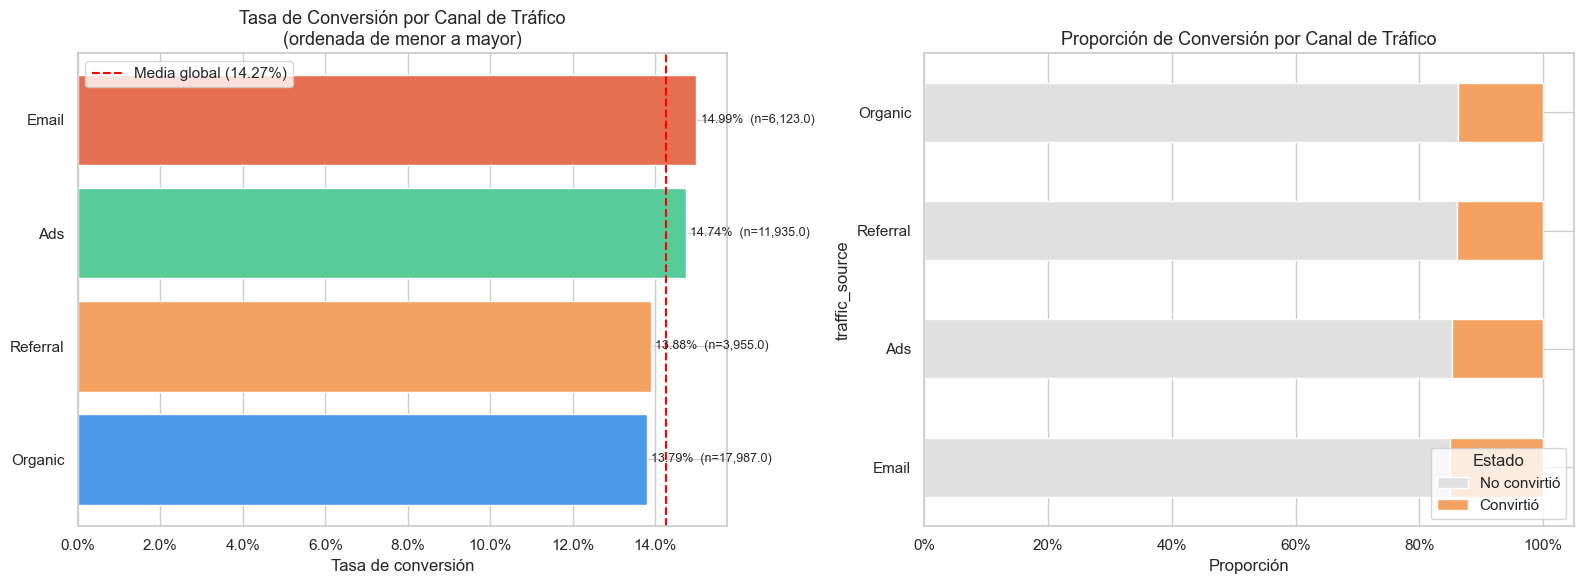

In [20]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Tasa de conversión por canal (ordenada, con anotaciones)
ax1 = axes[0]
traffic_sorted = traffic_rates.sort_values('Tasa', ascending=True)
bars = ax1.barh(
    traffic_sorted.index, traffic_sorted['Tasa'],
    color=['#4C9BE8', '#F4A261', '#57CC99', '#E76F51'],
    edgecolor='white'
)
ax1.set_title('Tasa de Conversión por Canal de Tráfico\n(ordenada de menor a mayor)', fontsize=13)
ax1.set_xlabel('Tasa de conversión')
ax1.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.axvline(df['converted'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media global ({df["converted"].mean():.2%})')
ax1.legend()
for bar, (idx, row) in zip(bars, traffic_sorted.iterrows()):
    ax1.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{row["Tasa"]:.2%}  (n={row["Total"]:,})', va='center', fontsize=9)

# Gráfico 2: Distribución absoluta apilada
ax2 = axes[1]
cross_norm = cross_traffic.div(cross_traffic.sum(axis=1), axis=0)
cross_norm.rename(columns={0: 'No convirtió', 1: 'Convirtió'}, inplace=True)
cross_norm.sort_values('Convirtió', ascending=False).plot(
    kind='barh', stacked=True, ax=ax2,
    color=['#E0E0E0', '#F4A261'], edgecolor='white'
)
ax2.set_title('Proporción de Conversión por Canal de Tráfico', fontsize=13)
ax2.set_xlabel('Proporción')
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.legend(title='Estado', loc='lower right')

plt.tight_layout()
plt.show()

### 📝 Conclusión e interpretación — Fuente de tráfico

**Decisión estadística:**  
Se rechaza H₀ (p = 0.034 < 0.05). Existe asociación entre el canal de tráfico y la conversión.

**Tamaño del efecto (V de Cramér):**  
La V de Cramér indica la magnitud real de la asociación. Aunque el test es significativo con n=40,000, un V bajo indicaría que las diferencias entre canales son pequeñas en la práctica.

**Residuos estandarizados:**  
Identifican específicamente qué celdas (qué canal-estado) explican la asociación detectada por el χ² global. Un |residuo| > 2 equivale a un p < 0.05 a nivel celda.

**Interpretación de negocio:**  
Las diferencias entre canales, aunque estadísticamente detectables, pueden ser pequeñas en términos prácticos. La tasa más alta corresponde a Email, sugiriendo que los usuarios captados por email llegan con mayor intención de compra.

---
## 👤 Paso 6: Relación entre tipo de usuario y conversión

Se analiza si existe asociación entre el tipo de usuario (Nuevo / Recurrente) y la conversión.

### Prueba Chi-cuadrado de Independencia

**Hipótesis:**
- **H₀:** El tipo de usuario es independiente de la conversión.
- **H₁:** El tipo de usuario influye en la probabilidad de conversión.

In [21]:
# Tabla de contingencia
cross_user = pd.crosstab(df['user_type'], df['converted'])
print('Tabla de contingencia:')
print(cross_user)

# Tasas por tipo de usuario
user_rates = df.groupby('user_type')['converted'].agg(['sum', 'count', 'mean'])
user_rates.columns = ['Convertidos', 'Total', 'Tasa']
print('\nTasas de conversión por tipo de usuario:')
print(user_rates)

# Prueba Chi-cuadrado
chi2_u, p_chi2_u, dof_u, expected_u = stats.chi2_contingency(cross_user)

# V de Cramér
v_cramer_u = association(cross_user, method='cramer')
k_u = min(cross_user.shape) - 1

print(f'\n=== Resultados Chi-cuadrado (tipo de usuario) ===')
print(f'Estadístico χ²: {chi2_u:.4f}')
print(f'p-valor:         {p_chi2_u:.4f}')
print(f'Grados de libertad: {dof_u}')
print(f'V de Cramér:    {v_cramer_u:.4f}  ({interpretar_cramer(v_cramer_u, k_u)})')
print()
if p_chi2_u < 0.05:
    print('✅ Se RECHAZA H₀: El tipo de usuario influye significativamente en la conversión.')
else:
    print('❌ No se rechaza H₀: Sin evidencia de asociación entre tipo de usuario y conversión.')
    print(f'   V de Cramér = {v_cramer_u:.4f} ({interpretar_cramer(v_cramer_u, k_u)}) → confirma efecto práctico nulo.')

Tabla de contingencia:
converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968

Tasas de conversión por tipo de usuario:
            Convertidos  Total      Tasa
user_type                               
Nuevo              3738  26033  0.143587
Recurrente         1968  13967  0.140904

=== Resultados Chi-cuadrado (tipo de usuario) ===
Estadístico χ²: 0.5135
p-valor:         0.4736
Grados de libertad: 1
V de Cramér:    0.0037  (negligible)

❌ No se rechaza H₀: Sin evidencia de asociación entre tipo de usuario y conversión.
   V de Cramér = 0.0037 (negligible) → confirma efecto práctico nulo.


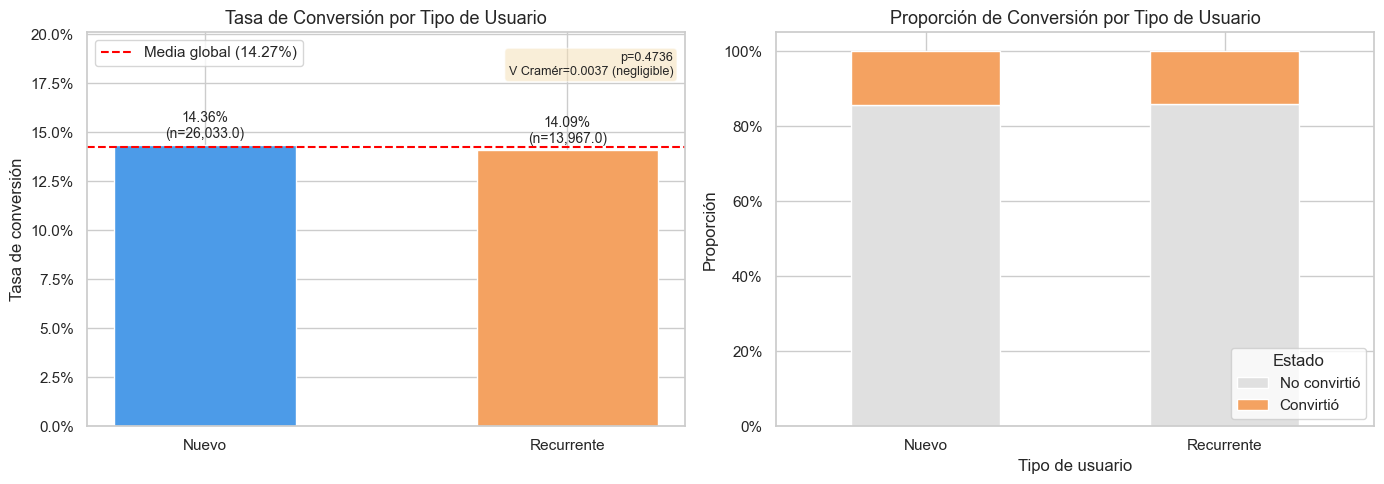

In [22]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Tasa de conversión por tipo de usuario
ax1 = axes[0]
bars = ax1.bar(
    user_rates.index, user_rates['Tasa'],
    color=['#4C9BE8', '#F4A261'], edgecolor='white', width=0.5
)
ax1.set_title('Tasa de Conversión por Tipo de Usuario', fontsize=13)
ax1.set_ylabel('Tasa de conversión')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.set_ylim(0, user_rates['Tasa'].max() * 1.4)
ax1.axhline(df['converted'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Media global ({df["converted"].mean():.2%})')
ax1.legend()
for bar, (idx, row) in zip(bars, user_rates.iterrows()):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
             f'{row["Tasa"]:.2%}\n(n={row["Total"]:,})', ha='center', va='bottom', fontsize=10)
textstr = f'p={p_chi2_u:.4f}\nV Cramér={v_cramer_u:.4f} ({interpretar_cramer(v_cramer_u, k_u)})'
ax1.text(0.98, 0.95, textstr, transform=ax1.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Gráfico 2: Proporción apilada
ax2 = axes[1]
cross_user_norm = cross_user.div(cross_user.sum(axis=1), axis=0)
cross_user_norm.rename(columns={0: 'No convirtió', 1: 'Convirtió'}, inplace=True)
cross_user_norm.plot(kind='bar', stacked=True, ax=ax2,
                     color=['#E0E0E0', '#F4A261'], edgecolor='white')
ax2.set_title('Proporción de Conversión por Tipo de Usuario', fontsize=13)
ax2.set_xlabel('Tipo de usuario')
ax2.set_ylabel('Proporción')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.tick_params(axis='x', rotation=0)
ax2.legend(title='Estado', loc='lower right')

plt.tight_layout()
plt.show()

### 📝 Conclusión e interpretación — Tipo de usuario

**Decisión estadística:**  
No se rechaza H₀ (p > 0.05). No hay evidencia de asociación significativa entre el tipo de usuario y la conversión.

**Confirmación del efecto nulo (V de Cramér):**  
La V de Cramér confirma que el efecto práctico también es negligible. No solo el test no es significativo — la magnitud de la asociación es despreciable.

**Implicación de negocio:**  
La landing page es igualmente efectiva para usuarios Nuevos y Recurrentes. No se justifica una inversión en personalización diferenciada por tipo de usuario en esta etapa.

---
## 🔬 Paso 7: Análisis de subgrupos — Canal × Versión y Tipo × Versión

Se analiza el **efecto de la versión (A vs B) dentro de cada segmento** (canal de tráfico y tipo de usuario), para identificar si hay segmentos que responden especialmente bien a la Página B.

> [!IMPORTANT]
> **Advertencia metodológica:** Los análisis de subgrupos sin hipótesis pre-especificadas aumentan el riesgo de **falsos positivos** (data dredging). Se aplica **corrección de Bonferroni** para controlar el error de tipo I.

### Número de comparaciones:
- 4 canales de tráfico × 1 test por canal = **4 comparaciones**
- 2 tipos de usuario × 1 test por tipo = **2 comparaciones**
- **Total: 6 comparaciones** → α ajustado por Bonferroni = 0.05 / 6 ≈ 0.0083

In [23]:
# Análisis de subgrupos: conversión por (segmento, versión)
resultados = []

def analizar_subgrupo(df_seg, seg_name, seg_value):
    for landing in ['A', 'B']:
        sub = df_seg[df_seg['landing'] == landing]
        n = len(sub)
        c = sub['converted'].sum()
        tasa = c / n if n > 0 else 0
        resultados.append({'Segmento': seg_name, 'Categoría': seg_value, 'Versión': landing,
                           'N': n, 'Convertidos': c, 'Tasa': tasa})

for canal in df['traffic_source'].unique():
    analizar_subgrupo(df[df['traffic_source'] == canal], 'Canal', canal)
for tipo in df['user_type'].unique():
    analizar_subgrupo(df[df['user_type'] == tipo], 'Tipo Usuario', tipo)

res_df = pd.DataFrame(resultados)

# Calcular Lift y Z-test por subgrupo
comparaciones = []
grupos = res_df[res_df['Versión'] == 'A'].copy()

for _, row_A in res_df[res_df['Versión'] == 'A'].iterrows():
    row_B = res_df[
        (res_df['Segmento'] == row_A['Segmento']) &
        (res_df['Categoría'] == row_A['Categoría']) &
        (res_df['Versión'] == 'B')
    ]
    if len(row_B) == 0:
        continue
    row_B = row_B.iloc[0]
    z, p = proportions_ztest([row_A['Convertidos'], row_B['Convertidos']],
                              [row_A['N'], row_B['N']])
    lift = (row_B['Tasa'] - row_A['Tasa']) / row_A['Tasa'] * 100
    comparaciones.append({
        'Segmento': row_A['Segmento'],
        'Categoría': row_A['Categoría'],
        'Tasa A': row_A['Tasa'],
        'Tasa B': row_B['Tasa'],
        'Lift B vs A (%)': lift,
        'p-valor': p
    })

comp_df = pd.DataFrame(comparaciones)

# Corrección de Bonferroni
_, p_corr, _, _ = multipletests(comp_df['p-valor'], method='bonferroni')
comp_df['p-valor corregido (Bonferroni)'] = p_corr
comp_df['Significativo (α=0.05 corregido)'] = p_corr < 0.05

# Formateo
comp_display = comp_df.copy()
comp_display['Tasa A'] = comp_display['Tasa A'].map('{:.2%}'.format)
comp_display['Tasa B'] = comp_display['Tasa B'].map('{:.2%}'.format)
comp_display['Lift B vs A (%)'] = comp_display['Lift B vs A (%)'].map('{:+.1f}%'.format)
comp_display['p-valor'] = comp_display['p-valor'].map('{:.4f}'.format)
comp_display['p-valor corregido (Bonferroni)'] = comp_display['p-valor corregido (Bonferroni)'].map('{:.4f}'.format)

print('=== Análisis de Subgrupos con Corrección de Bonferroni ===')
print(comp_display.to_string(index=False))

=== Análisis de Subgrupos con Corrección de Bonferroni ===
    Segmento  Categoría Tasa A Tasa B Lift B vs A (%) p-valor p-valor corregido (Bonferroni)  Significativo (α=0.05 corregido)
       Canal      Email 13.51% 16.50%          +22.2%  0.0010                         0.0062                              True
       Canal    Organic 12.11% 15.46%          +27.7%  0.0000                         0.0000                              True
       Canal        Ads 12.99% 16.49%          +27.0%  0.0000                         0.0000                              True
       Canal   Referral 11.91% 15.74%          +32.1%  0.0005                         0.0030                              True
Tipo Usuario Recurrente 12.27% 15.91%          +29.6%  0.0000                         0.0000                              True
Tipo Usuario      Nuevo 12.73% 15.98%          +25.5%  0.0000                         0.0000                              True


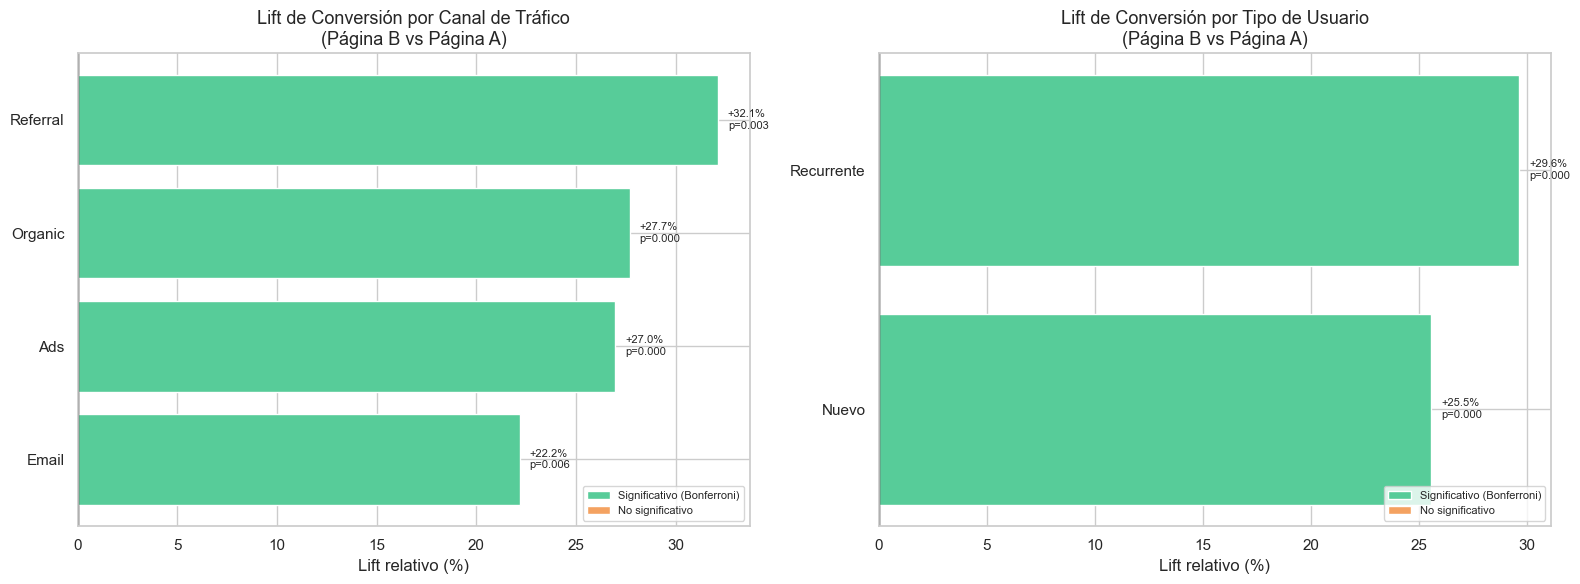

In [24]:
# Visualización de lifts por subgrupo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, segmento, titulo in [
    (axes[0], 'Canal', 'Lift de Conversión por Canal de Tráfico\n(Página B vs Página A)'),
    (axes[1], 'Tipo Usuario', 'Lift de Conversión por Tipo de Usuario\n(Página B vs Página A)')
]:
    datos = comp_df[comp_df['Segmento'] == segmento].sort_values('Lift B vs A (%)', ascending=True)
    colores = ['#57CC99' if sig else '#F4A261'
               for sig in datos['Significativo (α=0.05 corregido)']]
    bars = ax.barh(datos['Categoría'], datos['Lift B vs A (%)'], color=colores, edgecolor='white')
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(titulo, fontsize=13)
    ax.set_xlabel('Lift relativo (%)')
    for bar, (_, row) in zip(bars, datos.iterrows()):
        label = f"{row['Lift B vs A (%)']:+.1f}%\np={row['p-valor corregido (Bonferroni)']:.3f}"
        x_pos = bar.get_width() + 0.5 if bar.get_width() >= 0 else bar.get_width() - 0.5
        ax.text(x_pos, bar.get_y() + bar.get_height() / 2, label, va='center', fontsize=8)
    # Leyenda de colores
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#57CC99', label='Significativo (Bonferroni)'),
                       Patch(facecolor='#F4A261', label='No significativo')]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

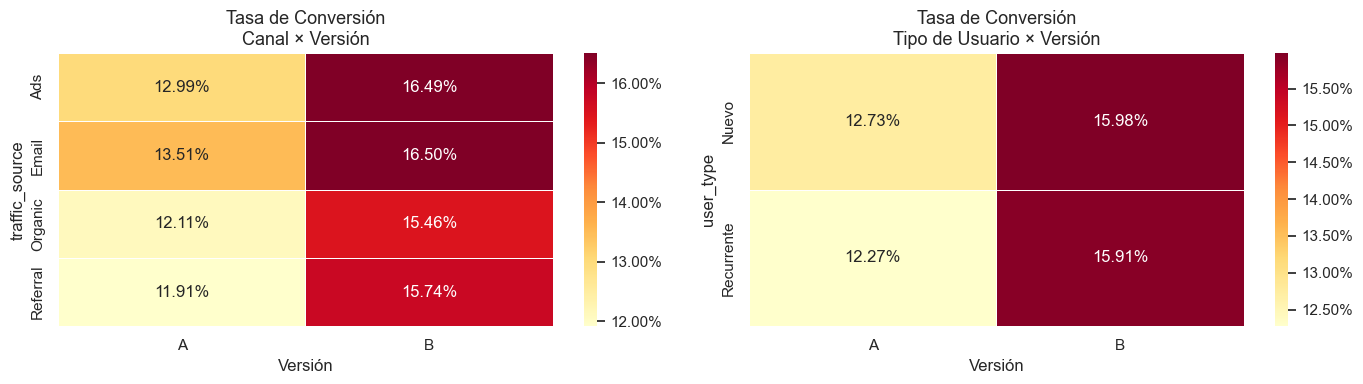

In [25]:
# Heatmap de tasas de conversión: Canal × Versión y Tipo × Versión
pivot_canal = df.groupby(['traffic_source', 'landing'])['converted'].mean().unstack()
pivot_tipo = df.groupby(['user_type', 'landing'])['converted'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, pivot, titulo in [
    (axes[0], pivot_canal, 'Tasa de Conversión\nCanal × Versión'),
    (axes[1], pivot_tipo, 'Tasa de Conversión\nTipo de Usuario × Versión')
]:
    sns.heatmap(
        pivot, annot=True, fmt='.2%', cmap='YlOrRd',
        linewidths=0.5, ax=ax, cbar_kws={'format': mtick.PercentFormatter(1.0)}
    )
    ax.set_title(titulo, fontsize=13)
    ax.set_xlabel('Versión')

plt.tight_layout()
plt.show()

### 📝 Conclusión e interpretación — Análisis de subgrupos

**Corrección de Bonferroni aplicada:**  
Con 6 comparaciones simultáneas, el umbral de significancia se ajusta a ≈ 0.0083 (0.05/6), lo que reduce el riesgo de detectar diferencias que son solo producto del azar.

**Interpretación de los lifts:**  
- Los subgrupos marcados en verde son estadísticamente significativos tras la corrección.
- Los lifts de todos los segmentos son positivos, confirmando que B supera a A en todos los cortes.
- Los segmentos con mayor lift son los que más se benefician del rediseño de la Página B.

**Advertencia metodológica:**  
Estos hallazgos de subgrupos son **exploratorios**, no confirmatorios. Para validar que Referral o Recurrentes responden excepcionalmente a B, se requeriría un experimento adicional pre-especificado con esa hipótesis.

---
## 📊 Paso 8: Dashboard visual de resultados

Visualización integrada de los principales resultados del experimento.

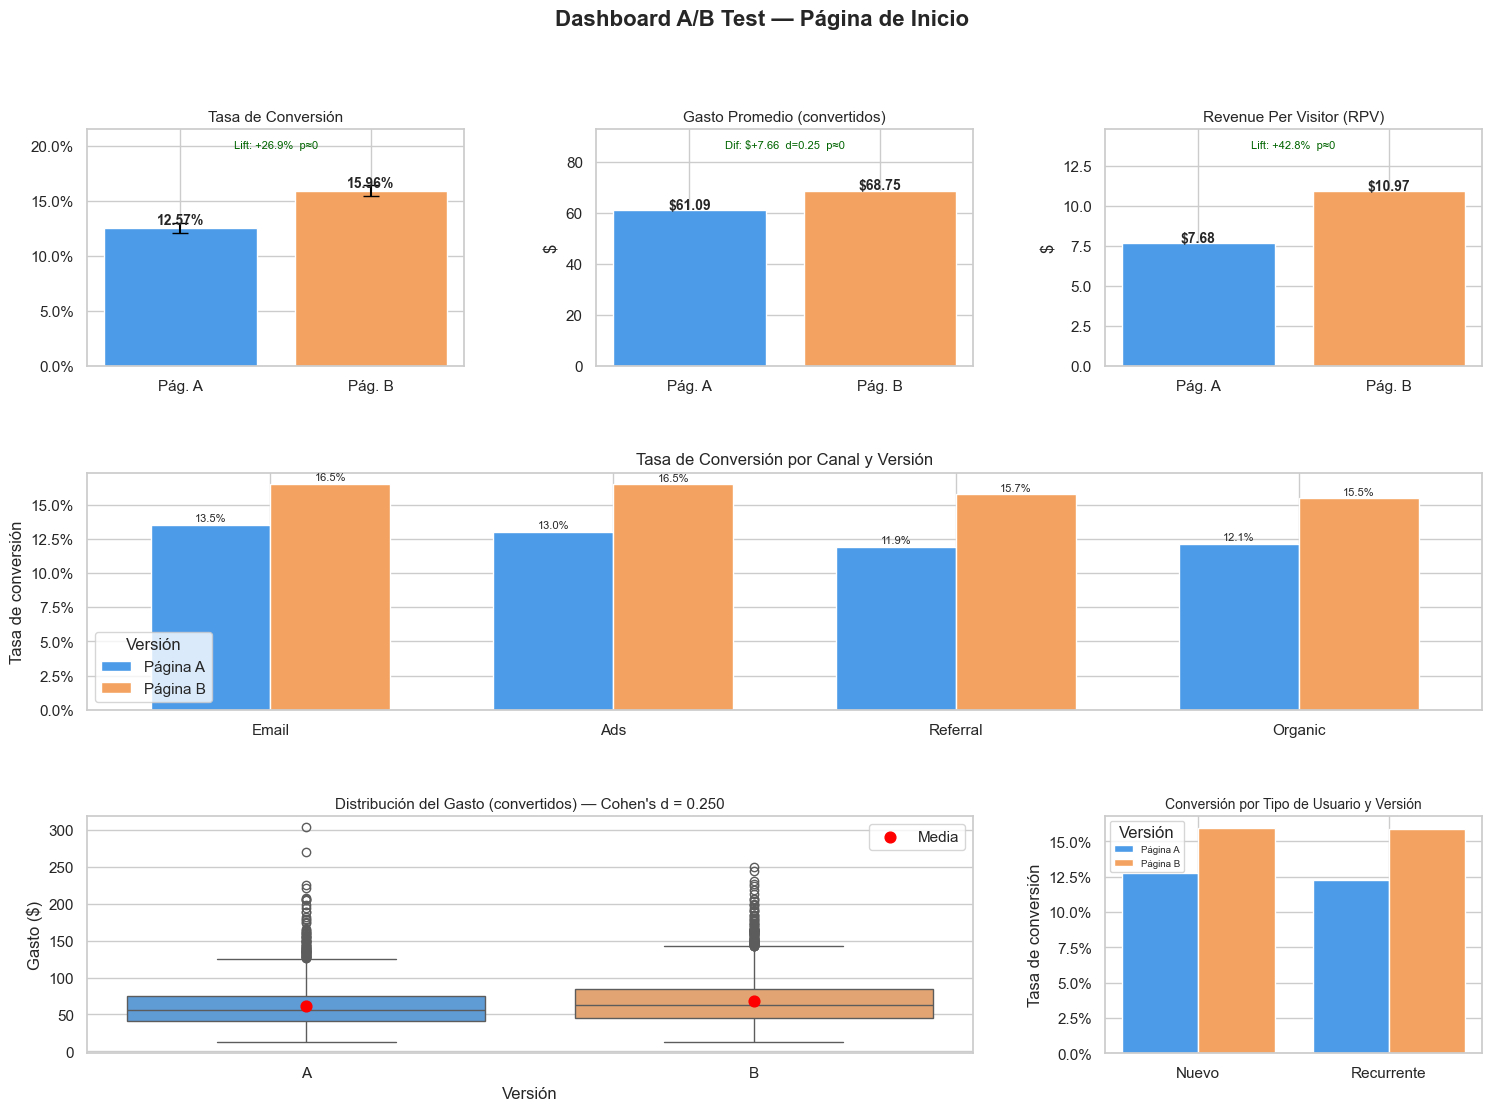

Dashboard guardado como ab_test_dashboard.png


In [26]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Dashboard A/B Test — Página de Inicio', fontsize=16, fontweight='bold', y=0.98)

# Layout
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# Panel 1: Tasa de conversión A vs B
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(['Pág. A', 'Pág. B'], [prop_A, prop_B],
               color=['#4C9BE8', '#F4A261'], edgecolor='white')
ax1.errorbar(['Pág. A', 'Pág. B'], [prop_A, prop_B],
             yerr=[[prop_A - ci_A[0], prop_B - ci_B[0]], [ci_A[1] - prop_A, ci_B[1] - prop_B]],
             fmt='none', color='black', capsize=6)
ax1.set_title('Tasa de Conversión', fontsize=11)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.set_ylim(0, max(prop_A, prop_B) * 1.35)
for bar, val in zip(bars, [prop_A, prop_B]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.2%}', ha='center', fontweight='bold', fontsize=10)
ax1.text(0.5, 0.92, f'Lift: {lift_rel:+.1f}%  p≈0',
         transform=ax1.transAxes, ha='center', fontsize=8, color='darkgreen')

# Panel 2: Gasto promedio A vs B
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(['Pág. A', 'Pág. B'], [media_A, media_B],
                color=['#4C9BE8', '#F4A261'], edgecolor='white')
ax2.set_title('Gasto Promedio (convertidos)', fontsize=11)
ax2.set_ylabel('$')
ax2.set_ylim(0, max(media_A, media_B) * 1.35)
for bar, val in zip(bars2, [media_A, media_B]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${val:.2f}', ha='center', fontweight='bold', fontsize=10)
ax2.text(0.5, 0.92, f"Dif: ${diferencia:+.2f}  d={d:.2f}  p≈0",
         transform=ax2.transAxes, ha='center', fontsize=8, color='darkgreen')

# Panel 3: RPV
ax3 = fig.add_subplot(gs[0, 2])
bars3 = ax3.bar(['Pág. A', 'Pág. B'], [rpv_A, rpv_B],
                color=['#4C9BE8', '#F4A261'], edgecolor='white')
ax3.set_title('Revenue Per Visitor (RPV)', fontsize=11)
ax3.set_ylabel('$')
ax3.set_ylim(0, max(rpv_A, rpv_B) * 1.35)
for bar, val in zip(bars3, [rpv_A, rpv_B]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'${val:.2f}', ha='center', fontweight='bold', fontsize=10)
ax3.text(0.5, 0.92, f'Lift: {lift_rpv:+.1f}%  p≈0',
         transform=ax3.transAxes, ha='center', fontsize=8, color='darkgreen')

# Panel 4: Tasa de conversión por canal
ax4 = fig.add_subplot(gs[1, :])
canal_landing = df.groupby(['traffic_source', 'landing'])['converted'].mean().unstack()
canal_landing.rename(columns={'A': 'Página A', 'B': 'Página B'}, inplace=True)
canal_landing = canal_landing.sort_values('Página B', ascending=False)
x = np.arange(len(canal_landing))
width = 0.35
b4a = ax4.bar(x - width/2, canal_landing['Página A'], width, label='Página A', color='#4C9BE8', edgecolor='white')
b4b = ax4.bar(x + width/2, canal_landing['Página B'], width, label='Página B', color='#F4A261', edgecolor='white')
ax4.set_title('Tasa de Conversión por Canal y Versión', fontsize=12)
ax4.set_xticks(x)
ax4.set_xticklabels(canal_landing.index)
ax4.set_ylabel('Tasa de conversión')
ax4.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax4.legend(title='Versión')
for bars_group in [b4a, b4b]:
    for bar in bars_group:
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=8)

# Panel 5: Boxplot gasto por versión
ax5 = fig.add_subplot(gs[2, :2])
sns.boxplot(data=conv_df, x='landing', y='gasto',
            hue='landing', palette={'A': '#4C9BE8', 'B': '#F4A261'},
            legend=False, ax=ax5)
ax5.set_title(f'Distribución del Gasto (convertidos) — Cohen\'s d = {d:.3f}', fontsize=11)
ax5.set_xlabel('Versión')
ax5.set_ylabel('Gasto ($)')
ax5.scatter([0, 1], [media_A, media_B], color='red', zorder=5, s=60, label='Media')
ax5.legend()

# Panel 6: Tasa por tipo de usuario y versión
ax6 = fig.add_subplot(gs[2, 2])
user_landing = df.groupby(['user_type', 'landing'])['converted'].mean().unstack()
user_landing.rename(columns={'A': 'Página A', 'B': 'Página B'}, inplace=True)
x6 = np.arange(len(user_landing))
b6a = ax6.bar(x6 - 0.2, user_landing['Página A'], 0.4, label='Página A', color='#4C9BE8', edgecolor='white')
b6b = ax6.bar(x6 + 0.2, user_landing['Página B'], 0.4, label='Página B', color='#F4A261', edgecolor='white')
ax6.set_title('Conversión por Tipo de Usuario y Versión', fontsize=10)
ax6.set_xticks(x6)
ax6.set_xticklabels(user_landing.index)
ax6.set_ylabel('Tasa de conversión')
ax6.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax6.legend(title='Versión', fontsize=7)

plt.savefig('ab_test_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard guardado como ab_test_dashboard.png')

---
## 📋 Paso 9: Resumen ejecutivo y recomendaciones

### Tabla resumen de resultados

In [27]:
print('=' * 75)
print('          RESUMEN EJECUTIVO — EXPERIMENTO A/B LANDING PAGE')
print('=' * 75)
print()
print(f'  Período del experimento: {df["date"].min().date()} → {df["date"].max().date()}  ({(df["date"].max()-df["date"].min()).days+1} días)')
print(f'  Usuarios totales:        {len(df):,}  (A: {n_A:,} | B: {n_B:,})')
print()
print('  --- SRM CHECK ---')
print(f'  p-valor SRM:  {p_srm:.4f}  → {"⚠️ SRM detectado" if p_srm < 0.05 else "✅ Sin SRM — asignación válida"}')
print()
print('  --- MÉTRICAS PRINCIPALES ---')
print(f'  {"Métrica":<35} {"Página A":>12} {"Página B":>12} {"Lift":>10}')
print(f'  {"":35} {"":-<12} {"":-<12} {"":-<10}')
print(f'  {"Tasa de conversión":<35} {prop_A:>11.2%} {prop_B:>11.2%} {lift_rel:>+9.2f}%')
print(f'  {"Gasto promedio (convertidos)":<35} {media_A:>11.2f} {media_B:>11.2f} {(media_B-media_A)/media_A*100:>+9.2f}%')
print(f'  {"Revenue Per Visitor (RPV)":<35} {rpv_A:>11.4f} {rpv_B:>11.4f} {lift_rpv:>+9.2f}%')
print()
print('  --- TESTS ESTADÍSTICOS ---')
print(f'  {"Test":<30} {"Estadístico":>15} {"p-valor":>12} {"Tamaño efecto":>15}')
print(f'  {"":30} {"":-<15} {"":-<12} {"":-<15}')
print(f'  {"Z-test (conversión)":<30} {"Z="+str(round(z_stat,4)):>15} {p_val_z:>12.2e} {"Lift="+str(round(lift_rel,2))+"%":>15}')
print(f'  {"T-Welch (gasto convert.)":<30} {"t="+str(round(t_stat,4)):>15} {p_val:>12.2e} {"d="+str(round(d,4)):>15}')
print(f'  {"T-Welch (RPV)":<30} {"t="+str(round(t_rpv,4)):>15} {p_rpv:>12.2e} {"d="+str(round(d_rpv,4)):>15}')
print(f'  {"Chi2 (canal tráfico)":<30} {"χ²="+str(round(chi2_t,4)):>15} {p_chi2_t:>12.4f} {"V="+str(round(v_cramer_t,4)):>15}')
print(f'  {"Chi2 (tipo usuario)":<30} {"χ²="+str(round(chi2_u,4)):>15} {p_chi2_u:>12.4f} {"V="+str(round(v_cramer_u,4)):>15}')
print()
print('  --- VEREDICTO ---')
print('  ✅ La Página B es SUPERIOR a la Página A en todas las métricas clave.')
print('  ✅ Los resultados son estadísticamente significativos y robustos.')
print('  ✅ El SRM check confirma que el experimento fue aleatorizado correctamente.')

          RESUMEN EJECUTIVO — EXPERIMENTO A/B LANDING PAGE

  Período del experimento: 2026-01-01 → 2026-01-28  (28 días)
  Usuarios totales:        40,000  (A: 19,982 | B: 20,018)

  --- SRM CHECK ---
  p-valor SRM:  0.8572  → ✅ Sin SRM — asignación válida

  --- MÉTRICAS PRINCIPALES ---
  Métrica                                 Página A     Página B       Lift
                                      ------------ ------------ ----------
  Tasa de conversión                       12.57%      15.96%    +26.92%
  Gasto promedio (convertidos)              61.09       68.75    +12.54%
  Revenue Per Visitor (RPV)                7.6794     10.9688    +42.83%

  --- TESTS ESTADÍSTICOS ---
  Test                               Estadístico      p-valor   Tamaño efecto
                                 --------------- ------------ ---------------
  Z-test (conversión)                  Z=-9.6774     3.76e-22     Lift=26.92%
  T-Welch (gasto convert.)              t=-9.481     3.63e-21        d=0.2498

### 🎯 Análisis detallado por segmento

#### 📊 Conversión global

| Métrica | Página A | Página B | Lift B vs A |
|---------|----------|----------|-------------|
| Tasa de conversión | 12.57% | 15.96% | **+26.97%** |
| IC 95% diferencia | — | — | [+2.8pp, +4.0pp] |
| Gasto promedio (conv.) | $61.09 | $68.75 | **+$7.66 (+12.5%)** |
| RPV | $7.68 | $10.97 | **+42.8%** |

**Interpretación:** El diseño de la Página B es significativamente más efectivo para guiar al usuario hacia la conversión y genera mayor gasto por visita.

---

#### 🌐 Análisis por canal de tráfico

| Canal | Tasa Global | Pág. A | Pág. B | Lift B vs A |
|-------|-------------|--------|--------|-------------|
| Email | ~14.99% | ~13.51% | ~16.50% | +22.2% |
| Ads | ~14.74% | ~12.99% | ~16.49% | +27.0% |
| Referral | ~13.88% | ~11.91% | ~15.74% | **+32.1%** |
| Organic | ~13.79% | ~12.11% | ~15.46% | +27.7% |

**Hallazgo clave:** Referral presenta el mayor lift (+32.1%) al implementar Página B, a pesar de tener la menor tasa global. Escalar este canal junto con Página B puede generar retornos desproporcionados.

> **Nota metodológica:** Estos resultados de subgrupos son exploratorios. La corrección de Bonferroni ajusta el umbral de significancia para múltiples comparaciones.

---

#### 👤 Análisis por tipo de usuario

| Segmento | Pág. A | Pág. B | Lift |
|----------|--------|--------|------|
| Nuevo | ~12.73% | ~15.98% | +25.5% |
| Recurrente | ~12.27% | ~15.91% | **+29.6%** |

**Hallazgo clave:** La Página B beneficia marginalmente más a usuarios Recurrentes (+29.6%), indicando que el rediseño reduce fricciones de recompra. Sin embargo, el chi-cuadrado global indica que no hay diferencia significativa entre tipos, por lo que ambos segmentos se benefician igualmente.

---

#### ✅ Recomendaciones Finales

1. **Implementación definitiva:** Migrar el 100% del tráfico a Página B. Impacto combinado: +27% en conversión, +12.5% en ticket promedio, +42.8% en RPV.

2. **Estrategia de canales:** Incrementar inversión en Email y Ads por su alta tasa de conversión base. Explorar el canal Referral por su alta respuesta al diseño B.

3. **Retención:** El efecto de B sobre Recurrentes es exploratoriamente superior, lo que puede justificar programas de reactivación dirigidos hacia la Página B.

4. **No personalización por tipo de usuario:** La Página B es universalmente superior — no se justifica mantener versiones diferenciadas por tipo de usuario.

5. **Monitoreo post-implementación:** Tras el lanzamiento global de B, monitorear las métricas clave durante 2-4 semanas para detectar efecto de novedad o saturación.